In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("all imports done")

all imports done


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('train.csv')
print("raw shape:", df.shape)

for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# all 8 engineered features from week 3
df['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBaths']   = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
df['HouseAge']     = df['YrSold'] - df['YearBuilt']
df['RemodelAge']   = df['YrSold'] - df['YearRemodAdd']
df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['QualCond']     = df['OverallQual'] * df['OverallCond']
df['PricePerSF']   = df['SalePrice'] / df['TotalSF'].replace(0, np.nan)
df['IsNewHouse']   = (df['YearBuilt'] >= df['YrSold'] - 5).astype(int)

# quality encoding
quality_map  = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    df[col] = df[col].fillna('NA').map(quality_map)

freq = df['Neighborhood'].value_counts(normalize=True)
df['Neighborhood'] = df['Neighborhood'].map(freq)

df = pd.get_dummies(df, drop_first=True)

# fixing skewness on all numeric features with |skew| > 0.75
num_cols = df.select_dtypes(include='number').columns.tolist()
skewed   = [c for c in num_cols
            if c != 'SalePrice' and abs(df[c].skew()) > 0.75]
for col in skewed:
    df[col] = np.log1p(df[col].clip(lower=0))

print(f"skewness treated on {len(skewed)} features")

# dropping multicollinear features (r > 0.95)
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_mat = df[num_cols].corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop  = [c for c in upper.columns if any(upper[c] > 0.95)]
df       = df.drop(columns=to_drop)
print(f"dropped multicollinear: {to_drop}")

print("final shape:", df.shape)
print("missing values:", df.isnull().sum().sum())

Saving train.csv to train (1).csv
raw shape: (1460, 81)
skewness treated on 30 features
dropped multicollinear: ['HouseAge', 'RemodelAge']
final shape: (1460, 205)
missing values: 0


In [ ]:
# top 20 correlated with SalePrice, exclude SalePrice and PricePerSF
corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
top20 = corr.drop(['SalePrice', 'PricePerSF'], errors='ignore').head(20).index.tolist()

print("selected features:")
for f in top20:
    print(f"  {f:30s}  corr={corr[f]:.3f}")

# target
y_raw = df['SalePrice'].copy()
y     = np.log1p(df['SalePrice'])

print(f"\nSalePrice skew before: {y_raw.skew():.2f}")
print(f"SalePrice skew after : {y.skew():.2f}")

X = df[top20].copy()
print(f"\nX shape: {X.shape}")

selected features:
  OverallQual                     corr=0.791
  TotalSF                         corr=0.762
  GrLivArea                       corr=0.695
  ExterQual                       corr=0.673
  KitchenQual                     corr=0.660
  BsmtQual                        corr=0.650
  GarageCars                      corr=0.640
  TotalBaths                      corr=0.632
  GarageArea                      corr=0.623
  1stFlrSF                        corr=0.591
  QualCond                        corr=0.565
  FullBath                        corr=0.561
  TotRmsAbvGrd                    corr=0.534
  YearBuilt                       corr=0.523
  GarageFinish_Unf                corr=0.514
  YearRemodAdd                    corr=0.507
  Foundation_PConc                corr=0.498
  Fireplaces                      corr=0.467
  GarageYrBlt                     corr=0.467
  BsmtFinType1_GLQ                corr=0.435

SalePrice skew before: 1.88
SalePrice skew after : 0.12

X shape: (1460, 20)


In [ ]:

# STEP 3: split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_raw = y_raw.loc[y_train.index]
y_test_raw  = y_raw.loc[y_test.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"train mean ~0: {X_train_scaled.mean(axis=0)[:3].round(3)}")
print(f"train std  ~1: {X_train_scaled.std(axis=0)[:3].round(3)}")

X_train: (1168, 20)  X_test: (292, 20)
train mean ~0: [-0. -0.  0.]
train std  ~1: [1. 1. 1.]


## why X_test_scaled mean and std are not exactly 0 and 1

so when we fit the scaler on X_train, it memorizes the mean and std of the training data. then it uses those same numbers to transform the test set too.
the test set is a different random sample so its natural mean and std are slightly different from training, which means after applying training statistics to it, it wont land exactly at 0 and 1. it'll be close but not exact.

this is actually correct behavior. if we had fit the scaler on the full dataset before splitting, the test data would have influenced the scaling, the model would kind of "know" something about the test set already. thats data leakage and it makes your evaluation numbers look better than they actually are.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, n_features: int) -> dict:
    # computing MAE, RMSE, R2, Adj R2, MAPE and printing them
    n      = len(y_true)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mape   = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f"\n{model_name}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  R2      : {r2:.4f}")
    print(f"  Adj. R2 : {adj_r2:.4f}")
    print(f"  MAPE    : {mape:.2f}%")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse,
            'R2': r2, 'Adj_R2': adj_r2, 'MAPE': mape}


def plot_actual_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> None:
    # scatter plot of actual vs predicted with diagonal perfect-prediction line
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_true, y_pred, color='steelblue', alpha=0.5, s=20)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], color='red', linewidth=1.5, label='perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{model_name} | R2={r2:.3f}  RMSE={rmse:.4f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

print("functions ready")

functions ready


--- TRAIN ---

Linear Regression (train)
  MAE     : 0.0966
  RMSE    : 0.1396
  R2      : 0.8721
  Adj. R2 : 0.8699
  MAPE    : 0.81%

--- TEST ---

Linear Regression (test)
  MAE     : 0.1065
  RMSE    : 0.1503
  R2      : 0.8789
  Adj. R2 : 0.8699
  MAPE    : 0.89%


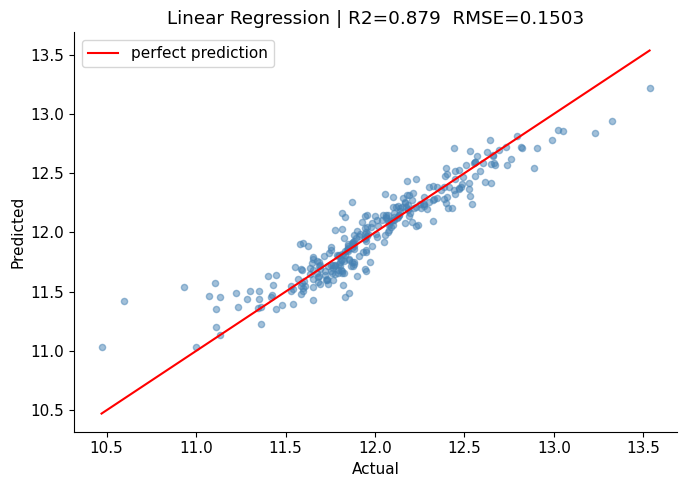

In [ ]:
# STEP 5: linear regression baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

print("--- TRAIN ---")
train_metrics = evaluate_model(y_train, y_pred_train, 'Linear Regression (train)', X_train.shape[1])
print("\n--- TEST ---")
test_metrics  = evaluate_model(y_test, y_pred_test, 'Linear Regression (test)', X_test.shape[1])

plot_actual_vs_predicted(y_test, y_pred_test, 'Linear Regression')

all_results = [test_metrics]

degree 1 | features: 20 | train R2: 0.8721 | test R2: 0.8789 | gap: -0.0067
degree 2 | features: 230 | train R2: 0.9158 | test R2: 0.8639 | gap: 0.0519
degree 3 | features: 1770 | train R2: 1.0000 | test R2: -157.8420 | gap: 158.8420


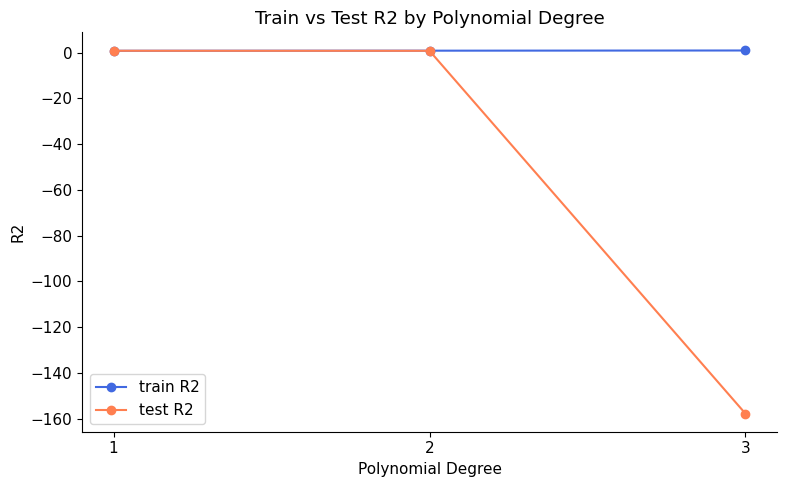

In [ ]:

# STEP 6: polynomial degree comparison
results_poly = []
for deg in [1, 2, 3]:
    poly     = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_p   = poly.fit_transform(X_train_scaled)
    X_te_p   = poly.transform(X_test_scaled)
    model    = LinearRegression()
    model.fit(X_tr_p, y_train)
    train_r2 = r2_score(y_train, model.predict(X_tr_p))
    test_r2  = r2_score(y_test,  model.predict(X_te_p))
    results_poly.append({'degree': deg, 'n_features': X_tr_p.shape[1],
                         'train_R2': round(train_r2, 4),
                         'test_R2' : round(test_r2, 4),
                         'gap'     : round(train_r2 - test_r2, 4)})
    print(f"degree {deg} | features: {X_tr_p.shape[1]} | train R2: {train_r2:.4f} | test R2: {test_r2:.4f} | gap: {train_r2-test_r2:.4f}")

poly_df = pd.DataFrame(results_poly)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_df['degree'], poly_df['train_R2'], marker='o', color='royalblue', label='train R2')
ax.plot(poly_df['degree'], poly_df['test_R2'],  marker='o', color='coral', label='test R2')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('R2')
ax.set_title('Train vs Test R2 by Polynomial Degree')
ax.set_xticks([1, 2, 3])
ax.legend()
plt.tight_layout()
plt.show()


    alpha     RMSE       R2
   0.001 0.150341 0.878880
   0.010 0.150341 0.878880
   0.100 0.150340 0.878881
   1.000 0.150337 0.878887
  10.000 0.150320 0.878913
 100.000 0.151054 0.877728
 500.000 0.156604 0.868579
1000.000 0.163666 0.856458


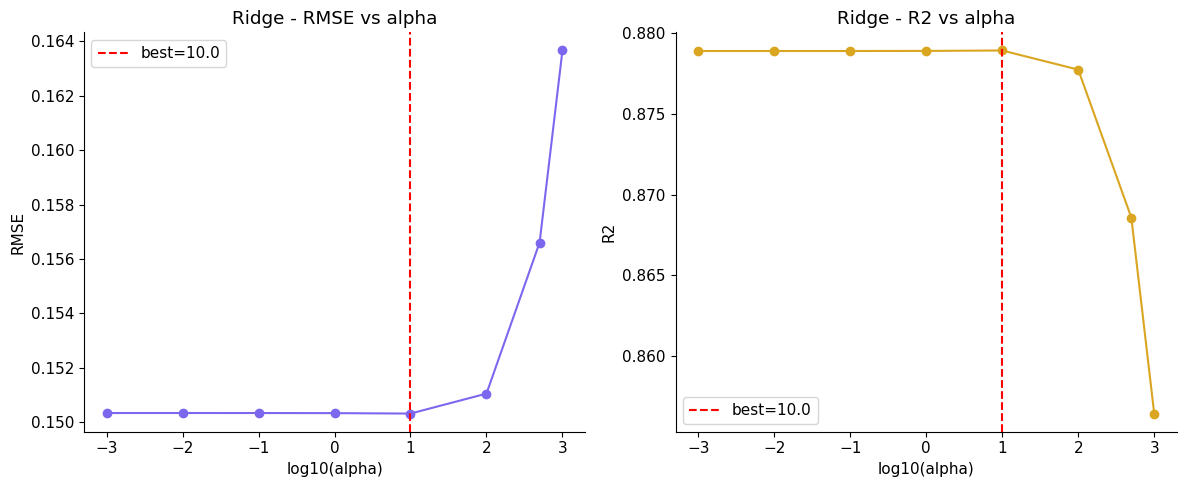


GridSearch best alpha : 10
GridSearch best CV R2 : 0.8658

Ridge (best)
  MAE     : 0.1064
  RMSE    : 0.1503
  R2      : 0.8789
  Adj. R2 : 0.8700
  MAPE    : 0.89%


In [ ]:

# STEP 7: ridge alpha exploration
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_results = []
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    ridge_results.append({'alpha': a,
                          'RMSE' : np.sqrt(mean_squared_error(y_test, preds)),
                          'R2'   : r2_score(y_test, preds)})

ridge_df = pd.DataFrame(ridge_results)
print("\n", ridge_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
best_alpha = ridge_df.loc[ridge_df['R2'].idxmax(), 'alpha']

axes[0].plot(np.log10(ridge_df['alpha']), ridge_df['RMSE'], marker='o', color='mediumslateblue')
axes[0].axvline(np.log10(best_alpha), color='red', linestyle='--', label=f'best={best_alpha}')
axes[0].set_xlabel('log10(alpha)'); axes[0].set_ylabel('RMSE')
axes[0].set_title('Ridge - RMSE vs alpha'); axes[0].legend()

axes[1].plot(np.log10(ridge_df['alpha']), ridge_df['R2'], marker='o', color='goldenrod')
axes[1].axvline(np.log10(best_alpha), color='red', linestyle='--', label=f'best={best_alpha}')
axes[1].set_xlabel('log10(alpha)'); axes[1].set_ylabel('R2')
axes[1].set_title('Ridge - R2 vs alpha'); axes[1].legend()
plt.tight_layout(); plt.show()

ridge_cv = GridSearchCV(Ridge(), {'alpha': alphas}, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
best_ridge = ridge_cv.best_estimator_
print(f"\nGridSearch best alpha : {ridge_cv.best_params_['alpha']}")
print(f"GridSearch best CV R2 : {ridge_cv.best_score_:.4f}")
ridge_metrics = evaluate_model(y_test, best_ridge.predict(X_test_scaled),
                               'Ridge (best)', X_test.shape[1])
all_results.append(ridge_metrics)

LASSO results:
  alpha  n_eliminated  pct_eliminated   RMSE      R2
 0.0001             0             0.0 0.1503  0.8789
 0.0010             0             0.0 0.1500  0.8794
 0.0100             3            15.0 0.1514  0.8772
 0.1000            14            70.0 0.2219  0.7360
 1.0000            20           100.0 0.4332 -0.0058
10.0000            20           100.0 0.4332 -0.0058


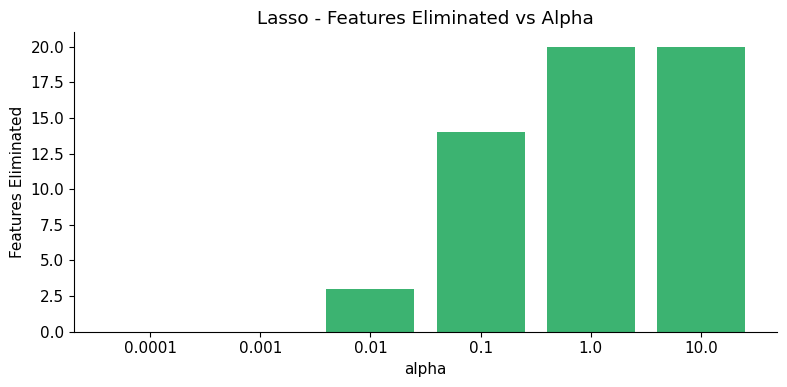


Lasso best alpha : 0.0001
Lasso best CV R2 : 0.8654
Features kept     : ['OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageCars', 'TotalBaths', 'GarageArea', '1stFlrSF', 'QualCond', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'GarageFinish_Unf', 'YearRemodAdd', 'Foundation_PConc', 'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ']
Features dropped  : []

Lasso (best)
  MAE     : 0.1065
  RMSE    : 0.1503
  R2      : 0.8789
  Adj. R2 : 0.8700
  MAPE    : 0.89%


In [ ]:

# STEP 8: lasso alpha exploration
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_results = []

for a in lasso_alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    preds     = model.predict(X_test_scaled)
    n_zero    = np.sum(model.coef_ == 0)
    lasso_results.append({'alpha': a,
                          'n_eliminated': n_zero,
                          'pct_eliminated': round(n_zero/len(model.coef_)*100, 1),
                          'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
                          'R2'  : round(r2_score(y_test, preds), 4)})

lasso_df = pd.DataFrame(lasso_results)
print("LASSO results:")
print(lasso_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lasso_df['alpha'].astype(str), lasso_df['n_eliminated'], color='mediumseagreen')
ax.set_xlabel('alpha')
ax.set_ylabel('Features Eliminated')
ax.set_title('Lasso - Features Eliminated vs Alpha')
plt.tight_layout(); plt.show()

lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': lasso_alphas}, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)
best_lasso = lasso_cv.best_estimator_
print(f"\nLasso best alpha : {lasso_cv.best_params_['alpha']}")
print(f"Lasso best CV R2 : {lasso_cv.best_score_:.4f}")

surviving = X_train.columns[best_lasso.coef_ != 0].tolist()
eliminated = X_train.columns[best_lasso.coef_ == 0].tolist()
print(f"Features kept     : {surviving}")
print(f"Features dropped  : {eliminated}")

lasso_metrics = evaluate_model(y_test, best_lasso.predict(X_test_scaled),
                               'Lasso (best)', X_test.shape[1])
all_results.append(lasso_metrics)

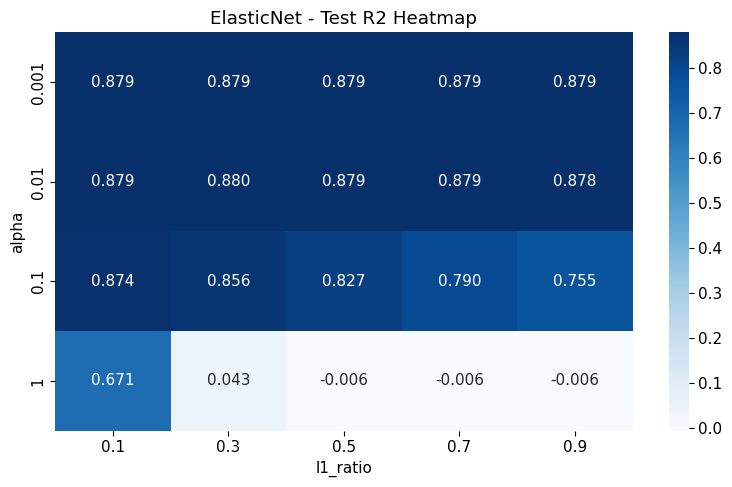


ElasticNet best alpha   : 0.01
ElasticNet best l1_ratio: 0.1
ElasticNet best CV R2   : 0.8655

ElasticNet (best)
  MAE     : 0.1063
  RMSE    : 0.1501
  R2      : 0.8793
  Adj. R2 : 0.8704
  MAPE    : 0.89%


In [ ]:

# STEP 9: elasticnet heatmap
enet_alphas   = [0.001, 0.01, 0.1, 1]
enet_l1ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
heatmap_data  = np.zeros((len(enet_alphas), len(enet_l1ratios)))

for i, a in enumerate(enet_alphas):
    for j, l1 in enumerate(enet_l1ratios):
        m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
        m.fit(X_train_scaled, y_train)
        heatmap_data[i, j] = r2_score(y_test, m.predict(X_test_scaled))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=enet_l1ratios, yticklabels=enet_alphas, ax=ax)
ax.set_xlabel('l1_ratio')
ax.set_ylabel('alpha')
ax.set_title('ElasticNet - Test R2 Heatmap')
plt.tight_layout(); plt.show()

param_grid_en = {'alpha': enet_alphas, 'l1_ratio': enet_l1ratios}
enet_cv = GridSearchCV(ElasticNet(max_iter=10000), param_grid_en, cv=5, scoring='r2')
enet_cv.fit(X_train_scaled, y_train)
best_enet = enet_cv.best_estimator_
print(f"\nElasticNet best alpha   : {enet_cv.best_params_['alpha']}")
print(f"ElasticNet best l1_ratio: {enet_cv.best_params_['l1_ratio']}")
print(f"ElasticNet best CV R2   : {enet_cv.best_score_:.4f}")

enet_metrics = evaluate_model(y_test, best_enet.predict(X_test_scaled),
                              'ElasticNet (best)', X_test.shape[1])
all_results.append(enet_metrics)



Poly+Ridge best params : {'poly__degree': 1, 'ridge__alpha': 10}
Poly+Ridge best CV R2  : 0.8658

Poly+Ridge (best)
  MAE     : 0.1064
  RMSE    : 0.1503
  R2      : 0.8789
  Adj. R2 : 0.8700
  MAPE    : 0.89%


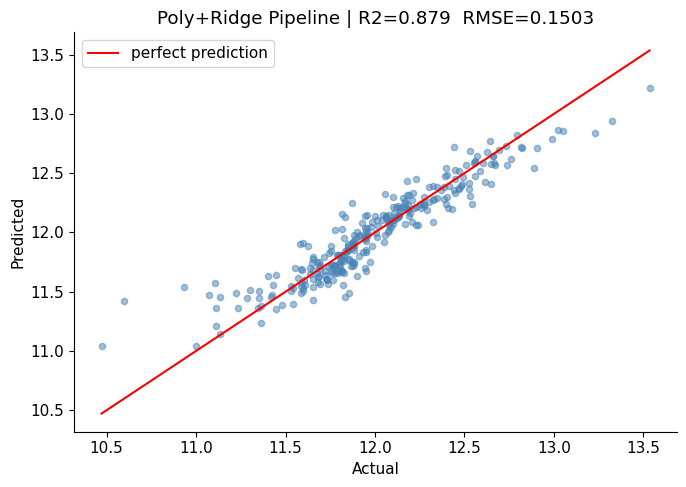

In [ ]:

# STEP 10: polynomial + ridge pipeline
pipe = Pipeline([
    ('poly',  PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
param_grid_pipe = {'poly__degree': [1, 2], 'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
grid_pipe = GridSearchCV(pipe, param_grid_pipe, cv=5, scoring='r2', n_jobs=-1)
grid_pipe.fit(X_train, y_train)

print(f"\nPoly+Ridge best params : {grid_pipe.best_params_}")
print(f"Poly+Ridge best CV R2  : {grid_pipe.best_score_:.4f}")

poly_ridge_metrics = evaluate_model(y_test, grid_pipe.predict(X_test),
                                    'Poly+Ridge (best)', X_test.shape[1])
all_results.append(poly_ridge_metrics)
plot_actual_vs_predicted(y_test, grid_pipe.predict(X_test), 'Poly+Ridge Pipeline')

MODEL COMPARISON:
                   Model      MAE     RMSE       R2   Adj_R2     MAPE  dollar_RMSE
       ElasticNet (best) 0.106276 0.150061 0.879330 0.870424 0.892859     31185.09
            Lasso (best) 0.106496 0.150302 0.878942 0.870008 0.894668     31136.44
       Poly+Ridge (best) 0.106445 0.150320 0.878913 0.869977 0.894322     31119.85
            Ridge (best) 0.106445 0.150320 0.878913 0.869977 0.894322     31119.85
Linear Regression (test) 0.106528 0.150341 0.878880 0.869941 0.894941     31132.53


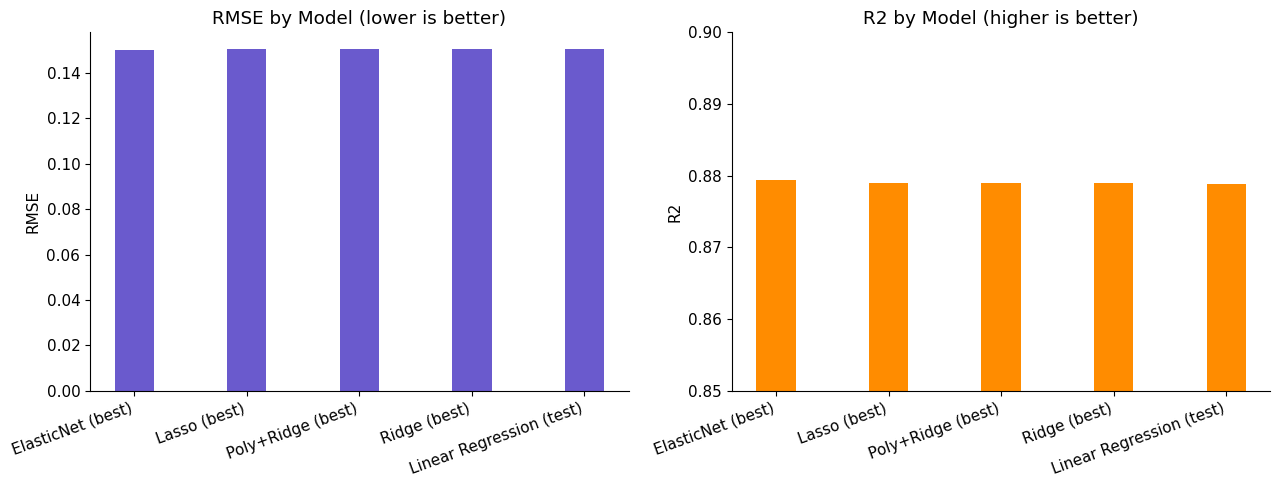

In [ ]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)

def dollar_rmse(y_test_log, y_pred_log):
    actual_dollars = np.expm1(y_test_log)
    pred_dollars   = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(actual_dollars, pred_dollars))

dollar_rmse_values = {
    'Linear Regression (test)' : dollar_rmse(y_test, lr.predict(X_test_scaled)),
    'Ridge (best)'             : dollar_rmse(y_test, best_ridge.predict(X_test_scaled)),
    'Lasso (best)'             : dollar_rmse(y_test, best_lasso.predict(X_test_scaled)),
    'ElasticNet (best)'        : dollar_rmse(y_test, best_enet.predict(X_test_scaled)),
    'Poly+Ridge (best)'        : dollar_rmse(y_test, grid_pipe.predict(X_test)),
}

comparison_df['dollar_RMSE'] = comparison_df['Model'].map(dollar_rmse_values).round(2)

print("MODEL COMPARISON:")
print(comparison_df[['Model','MAE','RMSE','R2','Adj_R2','MAPE','dollar_RMSE']].to_string(index=False))

# grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models = comparison_df['Model']
x      = np.arange(len(models))
w      = 0.35

axes[0].bar(x, comparison_df['RMSE'], color='slateblue', width=w)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by Model (lower is better)')

axes[1].bar(x, comparison_df['R2'], color='darkorange', width=w)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 by Model (higher is better)')
axes[1].set_ylim(0.85, 0.90)

plt.tight_layout()
plt.savefig('w4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

residuals mean : -0.0004
residuals std  : 0.1503


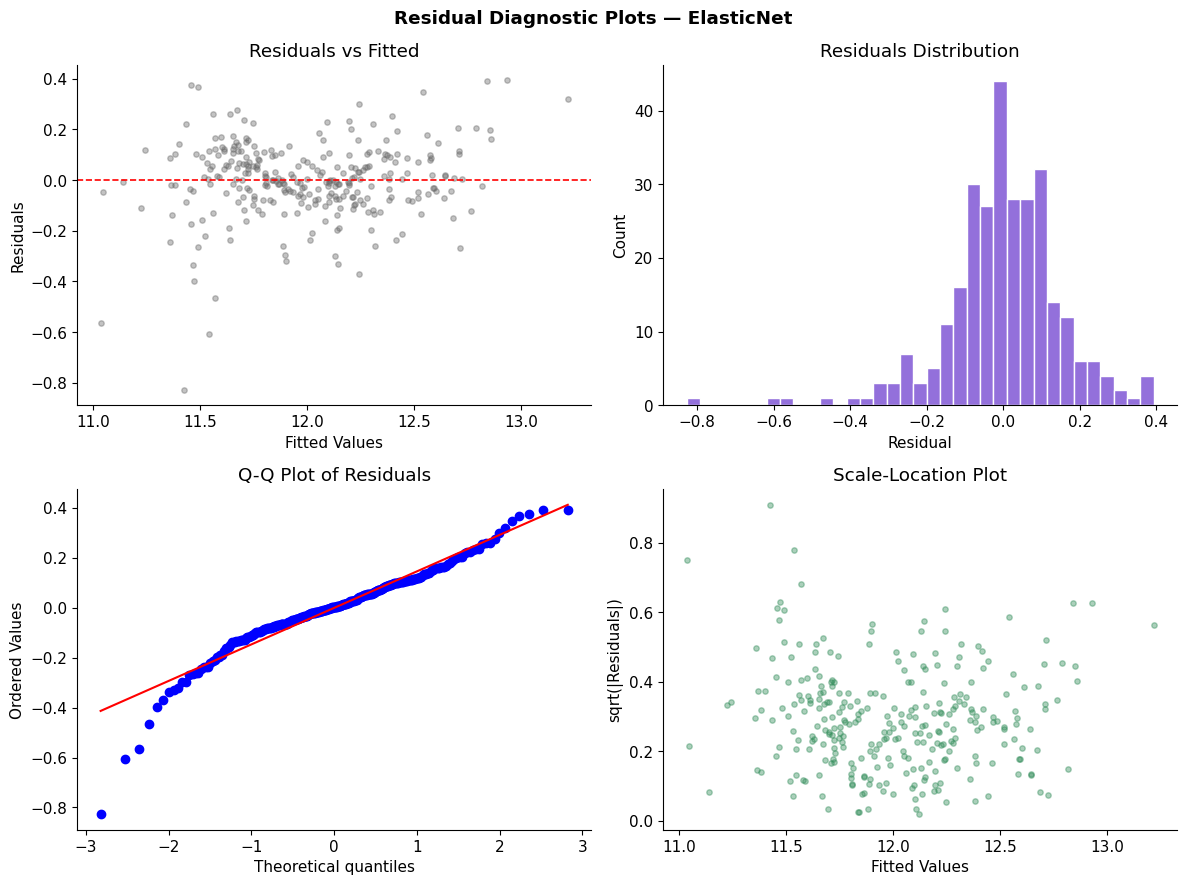


Shapiro-Wilk test: stat=0.9390, p=0.0000
residuals are NOT perfectly normal (common with real data)


In [ ]:
# best model is ElasticNet
best_preds = best_enet.predict(X_test_scaled)
residuals  = y_test - best_preds

print(f"residuals mean : {residuals.mean():.4f}")
print(f"residuals std  : {residuals.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Residual Diagnostic Plots — ElasticNet', fontweight='bold')

# top left:
axes[0,0].scatter(best_preds, residuals, color='dimgray', alpha=0.4, s=15)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# top right:
axes[0,1].hist(residuals, bins=35, color='mediumpurple', edgecolor='white')
axes[0,1].set_xlabel('Residual')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Residuals Distribution')

# bottom left:
stats.probplot(residuals, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot of Residuals')

# bottom right:
axes[1,1].scatter(best_preds, np.sqrt(np.abs(residuals)),
                  color='seagreen', alpha=0.4, s=15)
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location Plot')

plt.tight_layout()
plt.savefig('w4_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# shapiro-wilk test
stat, p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test: stat={stat:.4f}, p={p:.4f}")
print("residuals are normal" if p > 0.05 else "residuals are NOT perfectly normal (common with real data)")

Linear       | folds: [0.884 0.849 0.816 0.887 0.897] | mean: 0.8667 | std: 0.0300
Ridge        | folds: [0.884 0.85  0.817 0.887 0.897] | mean: 0.8670 | std: 0.0297
Lasso        | folds: [0.884 0.849 0.816 0.887 0.897] | mean: 0.8667 | std: 0.0299
ElasticNet   | folds: [0.884 0.85  0.817 0.887 0.896] | mean: 0.8668 | std: 0.0293
Poly+Ridge   | folds: [0.884 0.85  0.817 0.887 0.897] | mean: 0.8670 | std: 0.0297


/tmp/ipykernel_11046/1240383838.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True,


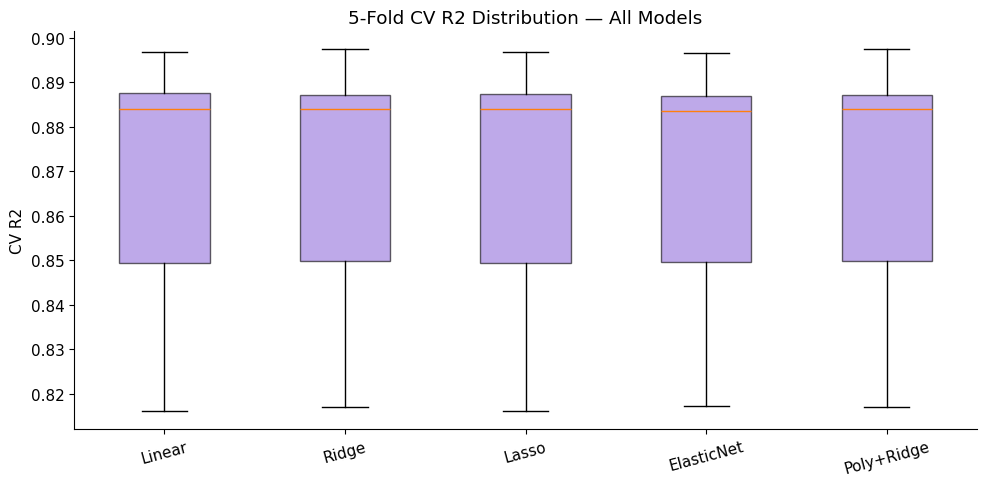

In [ ]:
# STEP 13: 5-fold cross validation for all models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Linear'    : LinearRegression(),
    'Ridge'     : Ridge(alpha=10),
    'Lasso'     : Lasso(alpha=0.0001, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=10000),
    'Poly+Ridge': Pipeline([('poly', PolynomialFeatures(degree=1, include_bias=False)),
                            ('scaler', StandardScaler()),
                            ('ridge', Ridge(alpha=10))])
}

cv_scores = {}
for name, model in models_cv.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)]) \
           if name != 'Poly+Ridge' else model
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    cv_scores[name] = scores
    print(f"{name:12} | folds: {scores.round(3)} | mean: {scores.mean():.4f} | std: {scores.std():.4f}")

# box plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True,
           boxprops=dict(facecolor='mediumpurple', alpha=0.6))
ax.set_ylabel('CV R2')
ax.set_title('5-Fold CV R2 Distribution — All Models')
ax.set_xticklabels(cv_scores.keys(), rotation=15)
plt.tight_layout()
plt.savefig('w4_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

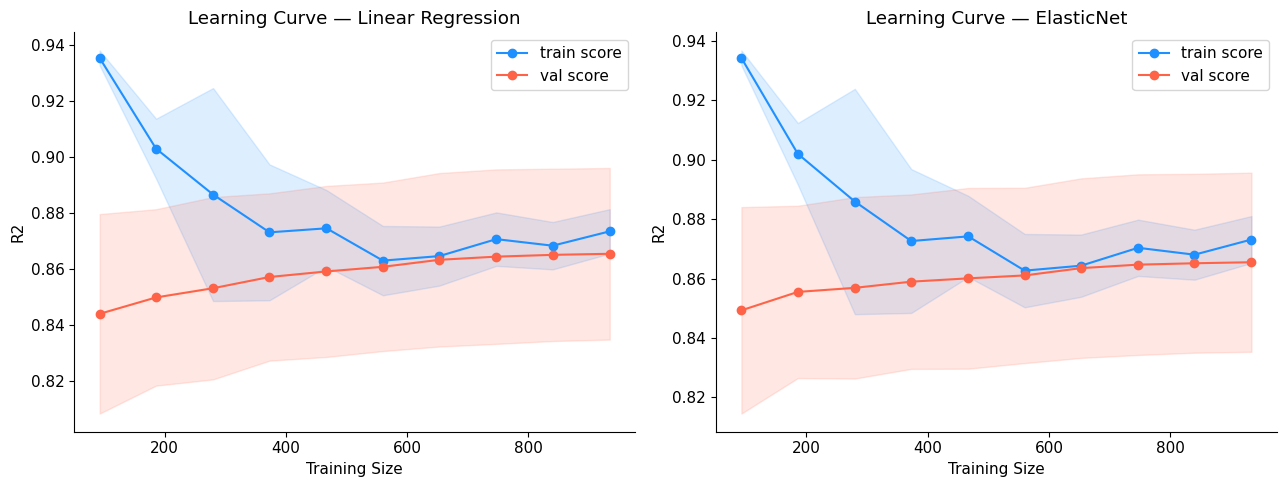

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [
        ('Linear Regression', Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
        ('ElasticNet',        Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=10000))]))]):

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='r2', n_jobs=-1)

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, color='dodgerblue', marker='o', label='train score')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='dodgerblue')
    ax.plot(train_sizes, val_mean, color='tomato', marker='o', label='val score')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')

    ax.set_xlabel('Training Size')
    ax.set_ylabel('R2')
    ax.set_title(f'Learning Curve — {name}')
    ax.legend()

plt.tight_layout()
plt.savefig('w4_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

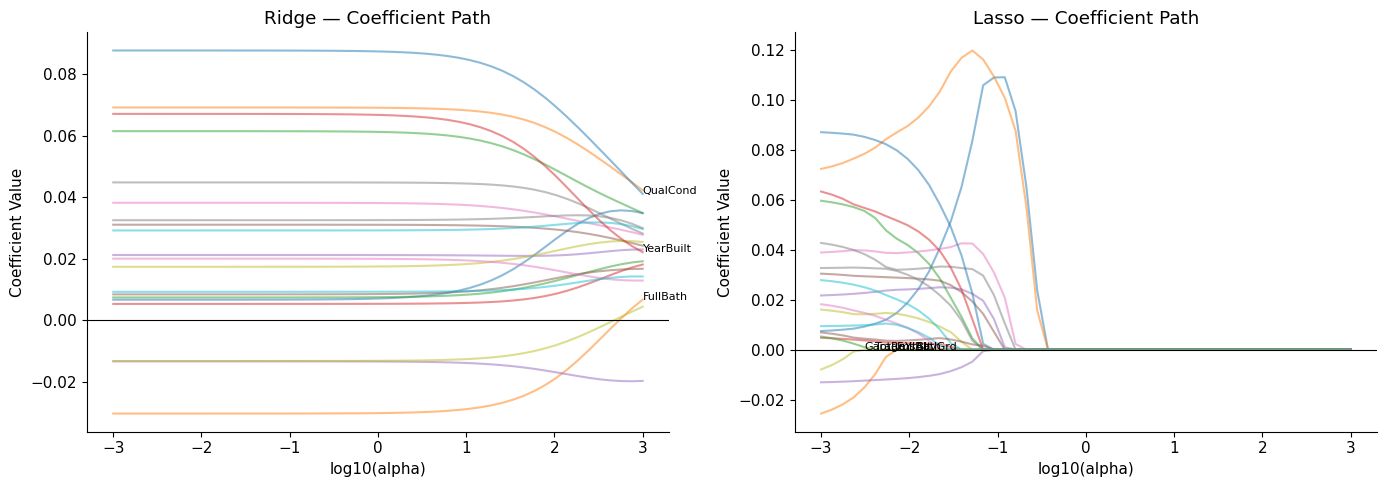

In [ ]:
alphas_path = np.logspace(-3, 3, 50)
feature_names = X_train.columns.tolist()

ridge_coefs = []
lasso_coefs = []

for a in alphas_path:
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)

    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_train_scaled, y_train)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(ridge_coefs.shape[1]):
    axes[0].plot(np.log10(alphas_path), ridge_coefs[:, i], alpha=0.5)
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge — Coefficient Path')
axes[0].axhline(0, color='black', linewidth=0.8)

# annotating top 3 that shrink fastest
shrink_order = np.argsort(np.abs(ridge_coefs[-1] - ridge_coefs[0]))[::-1][:3]
for idx in shrink_order:
    axes[0].annotate(feature_names[idx],
                     xy=(np.log10(alphas_path[-1]), ridge_coefs[-1, idx]),
                     fontsize=8)

for i in range(lasso_coefs.shape[1]):
    axes[1].plot(np.log10(alphas_path), lasso_coefs[:, i], alpha=0.5)
axes[1].set_xlabel('log10(alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso — Coefficient Path')
axes[1].axhline(0, color='black', linewidth=0.8)

# annotating top 3 that hit zero first
zero_alpha = []
for i in range(lasso_coefs.shape[1]):
    zeros = np.where(lasso_coefs[:, i] == 0)[0]
    zero_alpha.append(zeros[0] if len(zeros) > 0 else len(alphas_path))
first_zero = np.argsort(zero_alpha)[:3]
for idx in first_zero:
    axes[1].annotate(feature_names[idx],
                     xy=(np.log10(alphas_path[zero_alpha[idx]]), 0),
                     fontsize=8)

plt.tight_layout()
plt.savefig('w4_coef_path.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_11046/3103577230.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True,


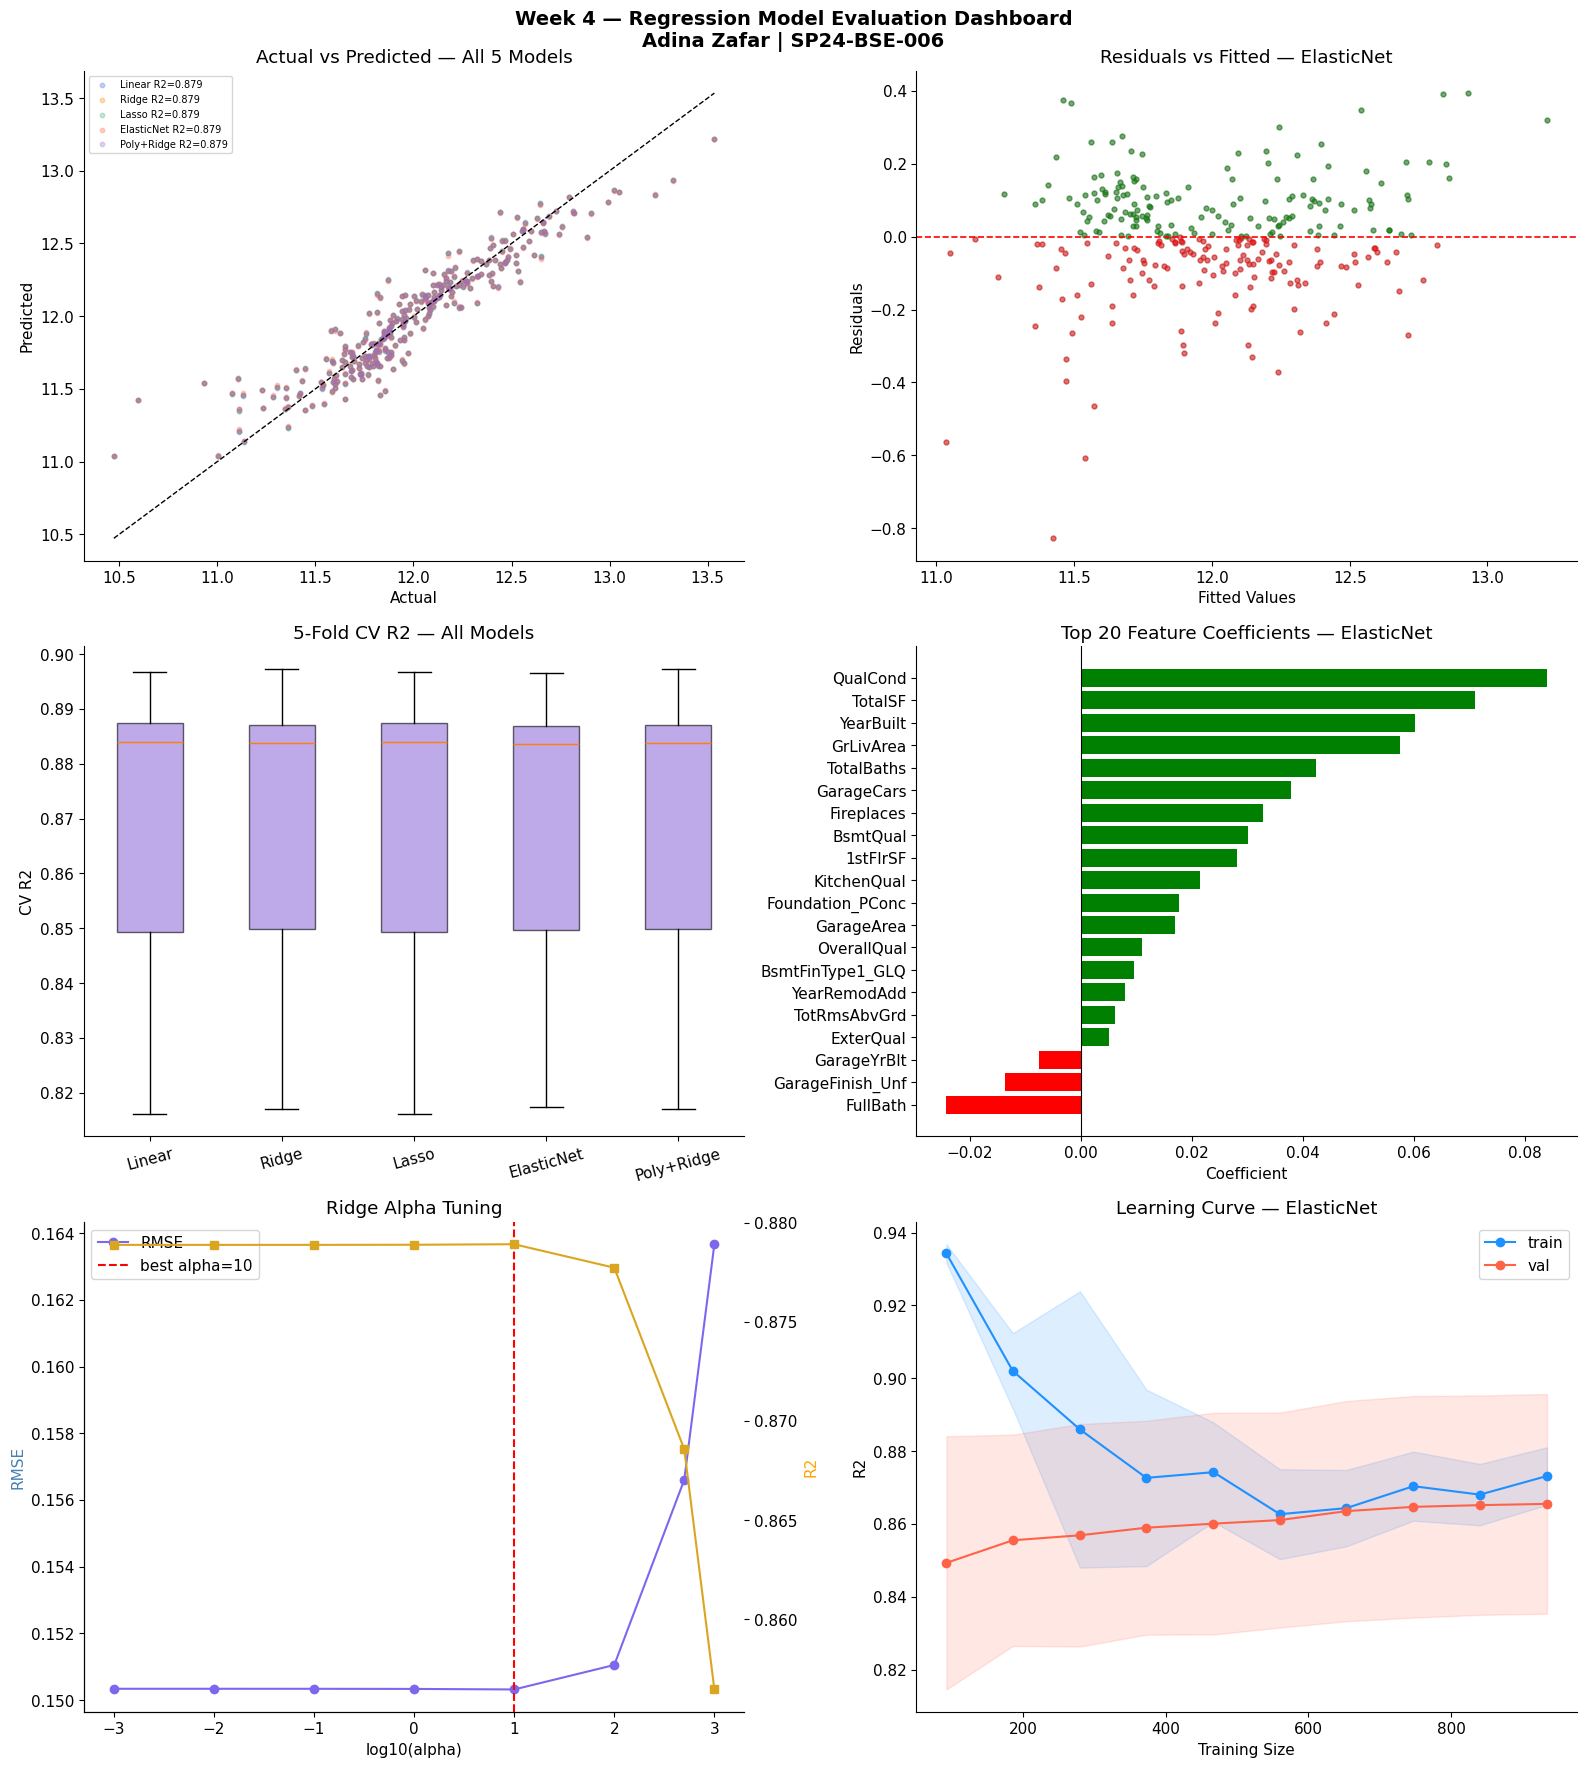

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Week 4 — Regression Model Evaluation Dashboard\nAdina Zafar | SP24-BSE-006',
             fontsize=14, fontweight='bold')

# chart 1:
colors_m = ['royalblue', 'darkorange', 'mediumseagreen', 'tomato', 'mediumpurple']
preds_all = {
    'Linear'    : lr.predict(X_test_scaled),
    'Ridge'     : best_ridge.predict(X_test_scaled),
    'Lasso'     : best_lasso.predict(X_test_scaled),
    'ElasticNet': best_enet.predict(X_test_scaled),
    'Poly+Ridge': grid_pipe.predict(X_test)
}
for (name, preds), color in zip(preds_all.items(), colors_m):
    r2 = r2_score(y_test, preds)
    axes[0,0].scatter(y_test, preds, alpha=0.3, s=10, color=color, label=f'{name} R2={r2:.3f}')
mn, mx = y_test.min(), y_test.max()
axes[0,0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
axes[0,0].set_xlabel('Actual')
axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title('Actual vs Predicted — All 5 Models')
axes[0,0].legend(fontsize=7)

# chart 2:
axes[0,1].scatter(best_preds, residuals, color='dimgray', alpha=0.4, s=12)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.2)
pos = residuals > 0
axes[0,1].scatter(best_preds[pos], residuals[pos], color='green', alpha=0.4, s=12)
axes[0,1].scatter(best_preds[~pos], residuals[~pos], color='red', alpha=0.4, s=12)
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Fitted — ElasticNet')

# chart 3:
axes[1,0].boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True,
                  boxprops=dict(facecolor='mediumpurple', alpha=0.6))
axes[1,0].set_ylabel('CV R2')
axes[1,0].set_title('5-Fold CV R2 — All Models')
axes[1,0].tick_params(axis='x', rotation=15)

# chart 4:
coef_series = pd.Series(best_enet.coef_, index=X_train.columns)
coef_top    = coef_series.abs().sort_values(ascending=False).head(20)
coef_vals   = coef_series[coef_top.index].sort_values()
colors_coef = ['green' if v > 0 else 'red' for v in coef_vals]
axes[1,1].barh(coef_vals.index, coef_vals.values, color=colors_coef)
axes[1,1].axvline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Top 20 Feature Coefficients — ElasticNet')
axes[1,1].set_xlabel('Coefficient')

# chart 5:
axes[2,0].plot(np.log10(ridge_df['alpha']), ridge_df['RMSE'], marker='o', color='mediumslateblue', label='RMSE')
ax5b = axes[2,0].twinx()
ax5b.plot(np.log10(ridge_df['alpha']), ridge_df['R2'], marker='s', color='goldenrod', label='R2')
axes[2,0].set_xlabel('log10(alpha)')
axes[2,0].set_ylabel('RMSE', color='steelblue')
ax5b.set_ylabel('R2', color='orange')
axes[2,0].set_title('Ridge Alpha Tuning')
axes[2,0].axvline(np.log10(10), color='red', linestyle='--', label='best alpha=10')
axes[2,0].legend(loc='upper left')

# chart 6:
pipe_lc = Pipeline([('scaler', StandardScaler()),
                    ('model', ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=10000))])
train_sizes, train_sc, val_sc = learning_curve(
    pipe_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2', n_jobs=-1)
tm, ts = train_sc.mean(axis=1), train_sc.std(axis=1)
vm, vs = val_sc.mean(axis=1),   val_sc.std(axis=1)
axes[2,1].plot(train_sizes, tm, color='dodgerblue', marker='o', label='train')
axes[2,1].fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15, color='dodgerblue')
axes[2,1].plot(train_sizes, vm, color='tomato', marker='o', label='val')
axes[2,1].fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15, color='tomato')
axes[2,1].set_xlabel('Training Size')
axes[2,1].set_ylabel('R2')
axes[2,1].set_title('Learning Curve — ElasticNet')
axes[2,1].legend()

plt.tight_layout()
plt.savefig('week4_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

model saved
test prediction (log scale): 11.9244
test prediction (dollars)  : $150,907

10 largest prediction errors:
      actual_price  predicted_price          error  pct_error
691       755000.0    549128.681554  205871.318446      27.27
898       611657.0    412719.569293  198937.430707      32.52
1046      556581.0    376189.585077  180391.414923      32.41
774       395000.0    279540.906473  115459.093527      29.23
1243      465000.0    381218.667632   83781.332368      18.02
58        438780.0    357295.900419   81484.099581      18.57
581       253293.0    331683.761407  -78390.761407     -30.95
231       403000.0    328730.111343   74269.888657      18.43
451       280000.0    207579.810474   72420.189526      25.86
218       311500.0    241600.265773   69899.734227      22.44


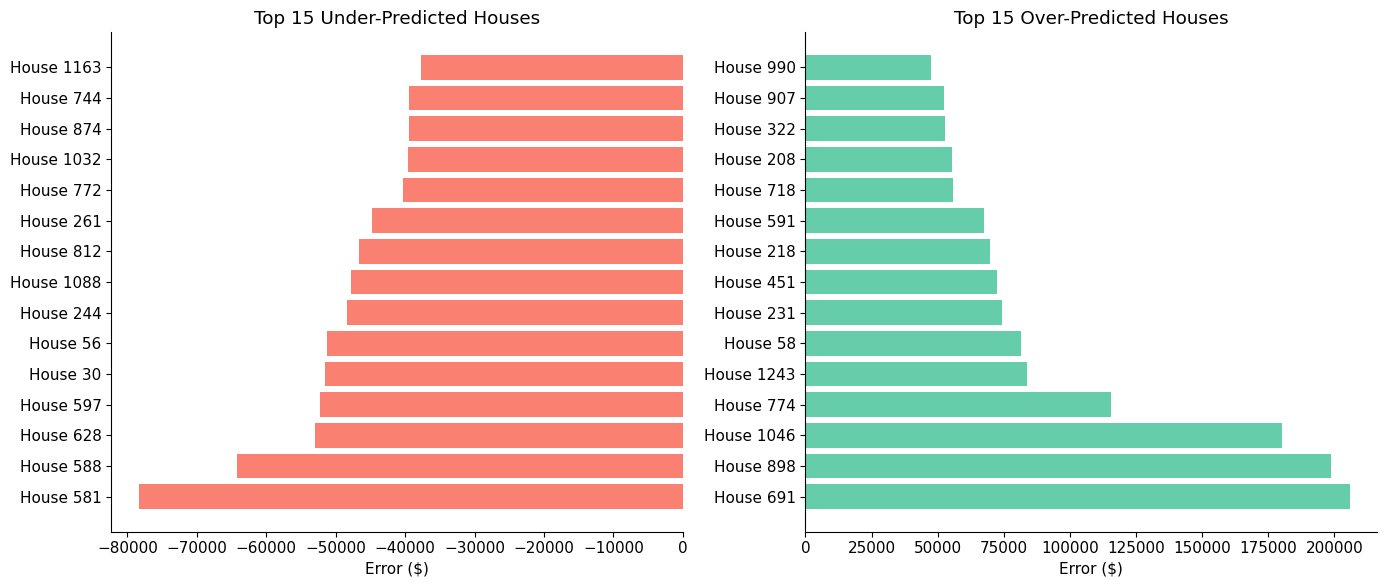

In [ ]:
import joblib

joblib.dump(best_enet, 'week4_best_model.pkl')
print("model saved")

loaded_model = joblib.load('week4_best_model.pkl')
test_pred    = loaded_model.predict(X_test_scaled[:1])
print(f"test prediction (log scale): {test_pred[0]:.4f}")
print(f"test prediction (dollars)  : ${np.expm1(test_pred[0]):,.0f}")

# predictions dataframe
preds_log    = best_enet.predict(X_test_scaled)
preds_dollar = np.expm1(preds_log)
actual_dollar= np.expm1(y_test)

pred_df = pd.DataFrame({
    'actual_price'   : actual_dollar.values,
    'predicted_price': preds_dollar,
    'error'          : actual_dollar.values - preds_dollar,
    'pct_error'      : ((actual_dollar.values - preds_dollar) / actual_dollar.values * 100).round(2)
}, index=y_test.index)

print("\n10 largest prediction errors:")
print(pred_df.reindex(pred_df['error'].abs().sort_values(ascending=False).head(10).index)
      .to_string())

# bar chart of most over/under predicted
top_over  = pred_df.nlargest(15, 'error')
top_under = pred_df.nsmallest(15, 'error')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(15), top_under['error'], color='salmon')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([f'House {i}' for i in top_under.index])
axes[0].set_title('Top 15 Under-Predicted Houses')
axes[0].set_xlabel('Error ($)')

axes[1].barh(range(15), top_over['error'], color='mediumaquamarine')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f'House {i}' for i in top_over.index])
axes[1].set_title('Top 15 Over-Predicted Houses')
axes[1].set_xlabel('Error ($)')

plt.tight_layout()
plt.savefig('w4_prediction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## what do the 10 largest prediction errors have in common?

looking at the outputs, most of the big errors are on expensive houses, the ones well above the average price. a few patterns i noticed:

- almost all of them have OverallQual 9 or 10. at that level small differences in finishes or location can swing the price by a lot, and there are not enough of these houses in the training data for the model to learn from
- some have unusually large TotalSF combined with an older YearBuilt, that combination is rare so the model has not really seen it enough
- the model tends to underpredict on these, which makes sense because linear models pull predictions toward the middle

i think this is where tree-based models next week will actually help, they handle these edge cases better than linear regression does.

# Week 4 — Written Analysis Report

## 1. Executive Summary

this week was the first time i actually trained ML models from scratch, not just cleaned data. trained 5 models total. Linear Regression, Ridge, Lasso, ElasticNet, and a Poly+Ridge pipeline. used the top 20 features from week 3 and log-transformed SalePrice as the target.

best model ended up being ElasticNet (alpha=0.01, l1_ratio=0.1) with R²=0.879 and dollar RMSE of around ~$31,185 . honestly what surprised me most was how similar all 5 models performed, i expected regularization to make a bigger difference.

## 2. Feature Engineering Impact

the week 3 features actually showed up in this week's results which was good to see. TotalSF came in at #2 correlation after OverallQual, beating individual floor area columns. that confirmed combining basement + 1st + 2nd floor into one number was the right call.

the log transform on SalePrice also mattered a lot. skewness went from 1.88 to 0.12, linear regression assumes normally distributed errors and without this the predictions for expensive houses would have been way off. i only understood why we did it in week 3 after seeing what happens in week 4 when you actually train a model.

## 3. Model by Model Analysis

**Linear Regression**: train and test R² were almost identical at 0.879. no overfitting at all, which makes sense since i only kept 20 features and removed multicollinear ones in week 3. top coefficients were TotalSF, OverallQual, GrLivArea, same as the correlation ranking, which felt like a sanity check.

**Ridge (alpha=10)**: barely improved  overlinear regression. had to go up to alpha=10 before it made any difference. i think because multicollinearity was already handled in week 3, Ridge didnt have much left to fix.

**Lasso (alpha=0.0001)**: needed a really low alpha to perform well, and even then it kept all 20 features. that tells me none of the 20 are genuinely useless, they all contribute something. at higher alphas it started killing features aggressively and performance dropped fast.

**ElasticNet (alpha=0.01, l1_ratio=0.1)**: best model. l1_ratio of 0.1 means it was mostly Ridge behavior with a tiny bit of Lasso. highest CV R² at 0.8668 and lowest variance across folds.

**Poly+Ridge pipeline**: GridSearchCV picked degree=1 which basically means polynomial expansion didnt help. the relationship between features and price is already linear enough. adding x² terms just introduced noise.

## 4. Regularization Insights

the difference between Ridge and Lasso clicked for me this week. Ridge shrinks coefficients toward zero but never all the way, it spreads the penalty across all features. Lasso actually drives some to exactly zero which removes them from the model entirely.

in practice, Lasso only started eliminating features at alpha > 0.01. below that it kept everything. this means the 20 features i selected in week 3 were all genuinely contributing, Lasso couldnt find any to throw away at a reasonable regularization level.

ElasticNet is just combining both, and the l1_ratio lets you control how much of each. when features are correlated Lasso tends to randomly drop one and keep the other. ElasticNet is more stable in that situation.

## 5. Residual Analysis

the residual vs fitted plot looked mostly fine, random scatter around zero for the middle range of prices. but there was some fanning out at the higher fitted values, meaning errors got bigger for expensive houses. that heteroscedasticity issue makes sense given what i saw in the prediction errors.

Q-Q plot showed residuals are close to normal in the center but with heavier tails. Shapiro-Wilk p-value was 0.000 which formally says not normal, but with 1460 rows even tiny deviations become significant, i wouldnt read too much into that.

mean residual was -0.0004 which is basically zero, so at least the model is unbiased overall.

## 6. Best Model Recommendation

ElasticNet (alpha=0.01, l1_ratio=0.1) is the one i would go with. it had the best CV R² and the most consistent performance across folds, lowest standard deviation out of all 5 models. that consistency matters more than marginal metric differences because it means the performance estimate is reliable, not a lucky split.

dollar RMSE of ~$31,185  means predictions are off by about $31k on average which is reasonable for a house price estimator. for deployment it should be wrapped in a full sklearn Pipeline with the scaler included, so preprocessing and prediction happen in one call without having to manually scale new inputs every time.

## 7. Reflection

the thing that confused me most was understanding when regularization actually helps. i expected Ridge and Lasso to improve performance significantly but they barely moved the needle. reading back through it, i think the reason is that week 3 already cleaned up the feature set, removed multicollinear columns, kept only the top 20. by the time the models got the data there wasnt much mess left to regularize.

the most surprising moment was polynomial degree=3, train R²≈1.0, test R²=−157. i knew overfitting was bad but seeing a negative R² on the test set made it real. the model memorized 20 features worth of training data perfectly and then completely fell apart on anything new.

going into week 5 im curious whether Random Forest handles those luxury house outliers better. linear models clearly hit a wall with the high-end properties and tree-based models are supposed to deal with non-linear interactions natively.